In [38]:
import pickle
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [9]:
print( f)

4WM_sweep_tp_medium_qubit1_00000.h5


In [65]:
# find the files with tp in the name from april 18 and load them into a list
folder = 'C:\\_Data\\SMPD\\2026_04_11_v2_calibration\\data\\'
files = [f for f in os.listdir(folder) if 'tp' in f]
files.sort()
data_list = []
# find files modified after april 18
for f in files:
    if os.path.getmtime(os.path.join(folder, f)) > 1713225600 and not '00000' in f:  # April 15, 2026
        print(f)
        with h5py.File(os.path.join(folder, f), 'r') as hf:
            # put all the data into a dictionary and append to the list
            data = {}
            for key in hf.keys():
                # if the shape of the data is (1,), then just take the value
                if hf[key].ndim == 0:
                    data[key] = hf[key]
                else:
                    data[key] = hf[key][:]

            
        # for each data file, check what the temperature was by looking at C:\\_Data\\SMPD\\2026_04_11_v2_calibration\\temperature_log.txt and finding the line with the filename it was taken on and extracting the temperature from that line and adding it to the data dictionary
        with open('C:\\_Data\\SMPD\\2026_04_11_v2_calibration\\temperature_log.txt', 'r') as temp_log:
            lines = temp_log.readlines()
            for line in lines:
                if f in line:
                    temp = line.split('Temperature: ')[1].split(' K')[0]
                    data['temperature_K'] = float(temp)
                    break
                
        data_list.append(data)
            



4WM_sweep_tp_medium_qubit1_00001.h5
4WM_sweep_tp_medium_qubit1_00002.h5
4WM_sweep_tp_medium_qubit1_00003.h5
4WM_sweep_tp_medium_qubit1_00004.h5
4WM_sweep_tp_medium_qubit1_00005.h5
4WM_sweep_tp_medium_qubit1_00006.h5
4WM_sweep_tp_medium_qubit1_00007.h5
4WM_sweep_tp_medium_qubit1_00008.h5
4WM_sweep_tp_medium_qubit1_00009.h5


In [49]:
data['p_e'].shape

(40,)

In [61]:
data['xpts']

array([ 1.00023674,  3.53732639,  6.07441604,  8.61150568, 11.14859533,
       13.68568497, 16.22277462, 18.75986427, 21.29695391, 23.83404356,
       26.37113321, 28.90822285, 31.4453125 , 33.98240215, 36.51949179,
       39.05658144, 41.59367109, 44.13076073, 46.66785038, 49.20494003,
       51.74202967, 54.27911932, 56.81620896, 59.35329861, 61.89038826,
       64.4274779 , 66.96456755, 69.5016572 , 72.03874684, 74.57583649,
       77.11292614, 79.65001578, 82.18710543, 84.72419508, 87.26128472,
       89.79837437, 92.33546402, 94.87255366, 97.40964331, 99.94673295])

(9, 40)
Skipping file 0 with shape (100,) because it does not match the expected shape 40
1 (40,)
2 (40,)
3 (40,)
4 (40,)
5 (40,)
6 (40,)
7 (40,)
8 (40,)
[0.    0.03  0.039 0.048 0.058 0.067 0.077 0.086 0.095]
(9,) (9, 40) (40,)


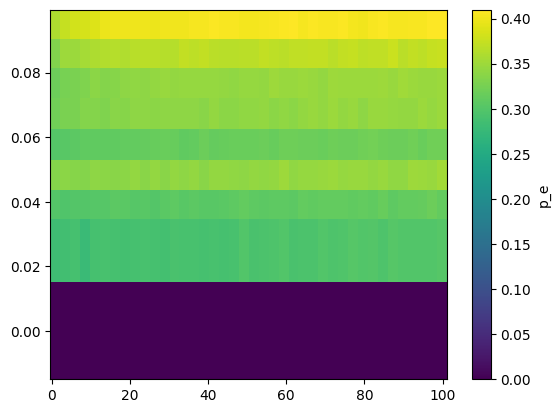

In [64]:
#empty vector for temperatures
temps = np.zeros(len(data_list))
#empty array for p_e
p_e_array = np.zeros((len(data_list), data_list[1]['p_e'].shape[0]))
print(p_e_array.shape)
for i, data in enumerate(data_list):
    # append p_e vectors as rows to the p_e_array
    if data['p_e'].shape[0] != p_e_array.shape[1]:
        print(f"Skipping file {i} with shape {data['p_e'].shape} because it does not match the expected shape {p_e_array.shape[1]}")
        continue
    print(i, data['p_e'].shape)
    p_e_array[i,:] = data['p_e']
    temps[i] = data['temperature_K']
print(temps)
print(temps.shape, p_e_array.shape,data['xpts'].shape)
plt.pcolormesh(data['xpts'],temps, p_e_array, shading='auto')
plt.colorbar(label='p_e')

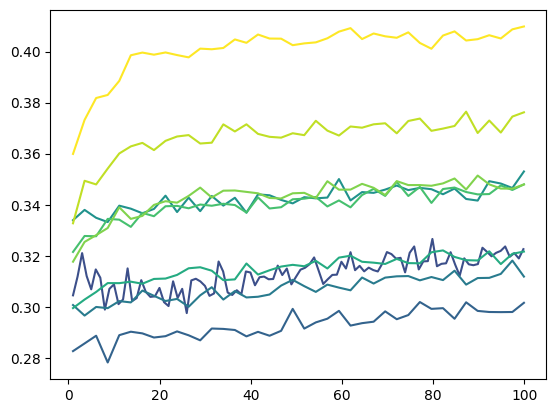

In [67]:
for data in data_list:
    # scale color by temperature
    plt.plot(data['xpts'], data['p_e'], label=f"{data['temperature_K']} K", color=plt.cm.viridis((data['temperature_K'] - temps.min()) / (temps.max() - temps.min())))